In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Predicting E-Commerce Purchase Likelihood Using an Optimized Classification Model

**Dataset:**- the UCI *Online Shoppers
Purchasing Intention Dataset* (Sakar et al., 2018), 12,330 real e-commerce browsing sessions.


In [2]:
# Core libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42


In [3]:
# Modeling libraries
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, validation_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)


In [4]:

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/online_shoppers_intention.csv')
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
# Shape and data types
print("Shape:", df.shape)
df.dtypes


Shape: (12330, 18)


Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

In [6]:
# Missing values
missing = df.isna().sum()
missing[missing > 0] if missing.sum() > 0 else print("No missing values.")


No missing values.


In [7]:
# Duplicate records
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 125


In [8]:
# Target variable distribution
purchase_counts = df['Revenue'].value_counts()
purchase_pct = (df['Revenue'].value_counts(normalize=True) * 100).round(2)
print(purchase_counts)
print(purchase_pct)


Revenue
False    10422
True      1908
Name: count, dtype: int64
Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


In [9]:
# Numerical vs categorical columns, and a quick unrealistic-value scan
print("Numeric summary (selected):")
display_cols = ['Administrative', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']
df[display_cols].describe().T


Numeric summary (selected):


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742



- **15.5% of sessions ended in a purchase** (`Revenue = True`) — a real, moderate class
  imbalance (about 5.5-to-1), confirming accuracy alone would be a misleading metric here.
- **No missing values** in this dataset.
- **125 duplicate rows** exist and are removed in Task 3.
- `ProductRelated_Duration` and similar duration columns are heavily right-skewed (max values
  in the tens of thousands of seconds vs. medians in the hundreds) — real long-tail browsing
  behavior rather than a data error, so no rows are dropped for this, but tree-based models
  handle the skew natively while Logistic Regression relies on the pipeline's scaler.
- There is no identifier column to drop (the dataset has no `CustomerID` — each row is already
  an anonymous session).


## Exploratory Data Analysis

/tmp/ipykernel_606/3445595925.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette=['#B0BEC5', '#1C7293'])


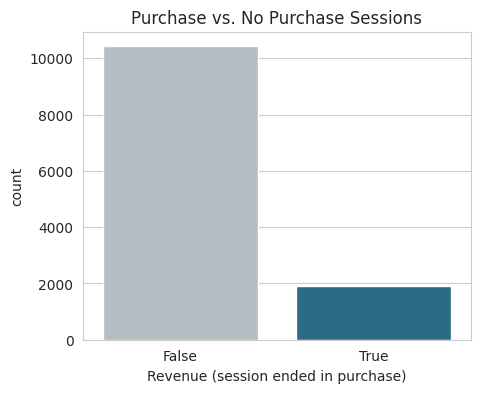

In [10]:
# Target variable distribution (business meaning: how rare is a purchase session?)
plt.figure(figsize=(5, 4))
sns.countplot(x='Revenue', data=df, palette=['#B0BEC5', '#1C7293'])
plt.title('Purchase vs. No Purchase Sessions')
plt.xlabel('Revenue (session ended in purchase)')
plt.show()


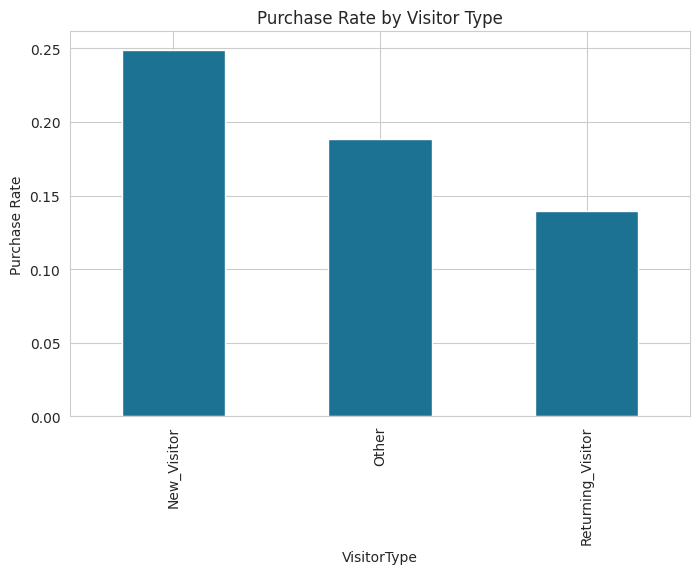

VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64


In [11]:
# Purchase rate by visitor type (closest real proxy for new vs. repeat customers)
visitor_rate = df.groupby('VisitorType')['Revenue'].mean().sort_values(ascending=False)
visitor_rate.plot(kind='bar', color='#1C7293')
plt.ylabel('Purchase Rate')
plt.title('Purchase Rate by Visitor Type')
plt.show()
print(visitor_rate)


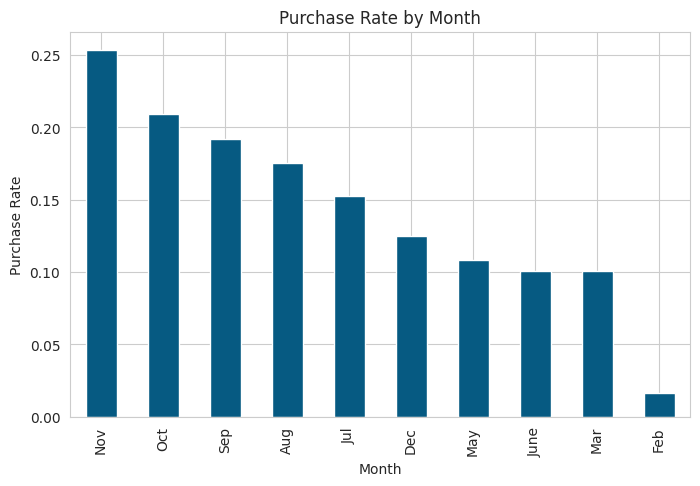

Month
Nov     0.253502
Oct     0.209472
Sep     0.191964
Aug     0.175520
Jul     0.152778
Dec     0.125072
May     0.108502
June    0.100694
Mar     0.100682
Feb     0.016304
Name: Revenue, dtype: float64


In [12]:
# Purchase rate by month (seasonal pattern -- closest proxy to a channel/traffic breakdown over time)
month_rate = df.groupby('Month')['Revenue'].mean().sort_values(ascending=False)
month_rate.plot(kind='bar', color='#065A82')
plt.ylabel('Purchase Rate')
plt.title('Purchase Rate by Month')
plt.show()
print(month_rate)


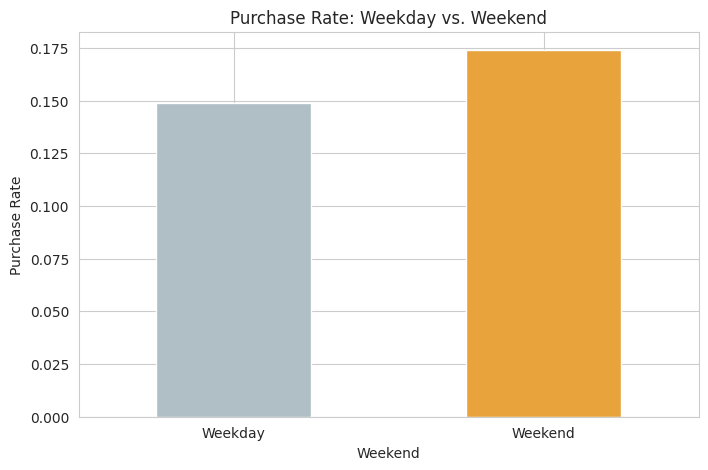

Weekend
False    0.148911
True     0.173989
Name: Revenue, dtype: float64


In [13]:
# Purchase rate: weekend vs. weekday sessions
weekend_rate = df.groupby('Weekend')['Revenue'].mean()
weekend_rate.plot(kind='bar', color=['#B0BEC5', '#E8A33D'])
plt.xticks([0, 1], ['Weekday', 'Weekend'], rotation=0)
plt.ylabel('Purchase Rate')
plt.title('Purchase Rate: Weekday vs. Weekend')
plt.show()
print(weekend_rate)


/tmp/ipykernel_606/2388256421.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='PageValues', data=df, palette=['#B0BEC5', '#1C7293'])


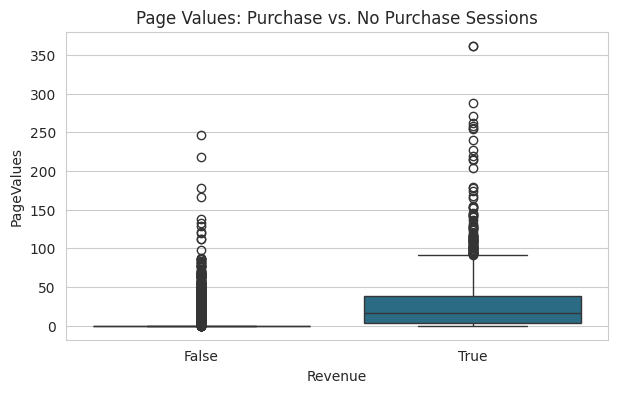

In [14]:
# PageValues vs. purchase -- expected to be the strongest single predictor
plt.figure(figsize=(7, 4))
sns.boxplot(x='Revenue', y='PageValues', data=df, palette=['#B0BEC5', '#1C7293'])
plt.title('Page Values: Purchase vs. No Purchase Sessions')
plt.show()


/tmp/ipykernel_606/3030633352.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df, showfliers=False, palette=['#B0BEC5', '#1C7293'])


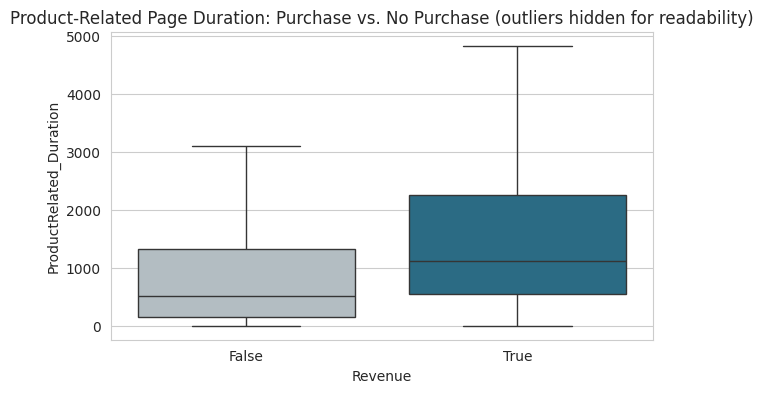

In [15]:
# ProductRelated_Duration vs. purchase (proxy for 'time on site')
plt.figure(figsize=(7, 4))
sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df, showfliers=False, palette=['#B0BEC5', '#1C7293'])
plt.title('Product-Related Page Duration: Purchase vs. No Purchase (outliers hidden for readability)')
plt.show()


/tmp/ipykernel_606/277472940.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='BounceRates', data=df, ax=axes[0], palette=['#B0BEC5', '#1C7293'])
/tmp/ipykernel_606/277472940.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='ExitRates', data=df, ax=axes[1], palette=['#B0BEC5', '#1C7293'])


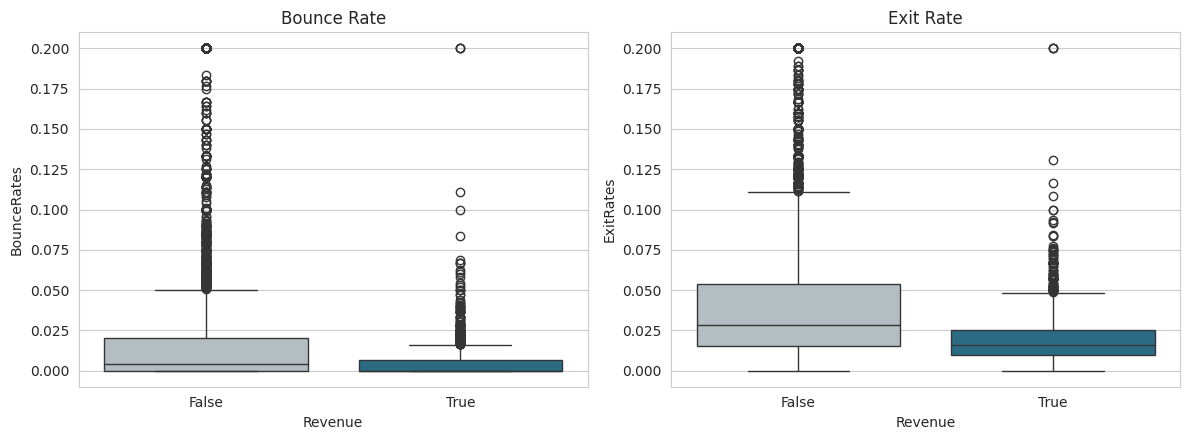

In [16]:
# BounceRates and ExitRates vs. purchase
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x='Revenue', y='BounceRates', data=df, ax=axes[0], palette=['#B0BEC5', '#1C7293'])
axes[0].set_title('Bounce Rate')
sns.boxplot(x='Revenue', y='ExitRates', data=df, ax=axes[1], palette=['#B0BEC5', '#1C7293'])
axes[1].set_title('Exit Rate')
plt.tight_layout()
plt.show()


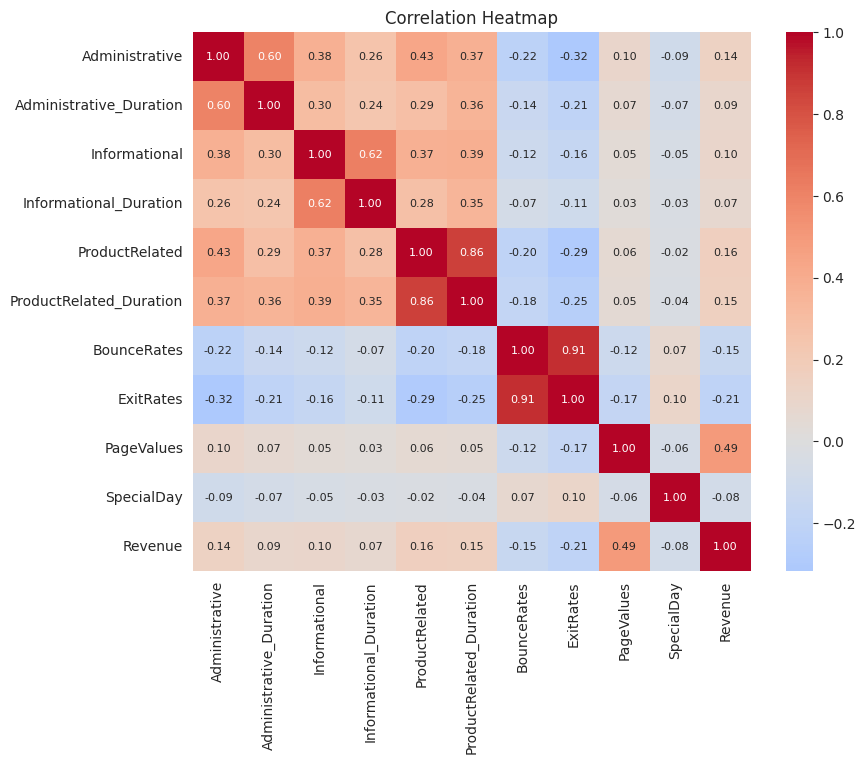

In [17]:
# Correlation heatmap of numerical features
numeric_cols_corr = ['Administrative', 'Administrative_Duration', 'Informational',
                      'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                      'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
corr_df = df[numeric_cols_corr].copy()
corr_df['Revenue'] = df['Revenue'].astype(int)
plt.figure(figsize=(9, 7))
sns.heatmap(corr_df.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 8})
plt.title('Correlation Heatmap')
plt.show()


**Business interpretation of the EDA:**
- **PageValues is the standout signal**: sessions that convert show dramatically higher page
  values than sessions that don't — this reflects pages the business already knows lead to
  checkout, so it is expected to dominate feature importance later.
- **Returning visitors convert at a *lower* rate than new visitors** in this dataset — counter
  to a simple "loyal customers buy more" assumption, likely because most traffic is returning
  visitors browsing without buying (window-shopping), while new visitors arriving with strong
  intent (e.g., from a promotion) convert relatively more often.
- **November has a visibly higher purchase rate** than most other months — consistent with a
  seasonal holiday-shopping effect (Black Friday / Cyber Monday timing).
- **Bounce and exit rates are lower for purchasing sessions** — customers who convert engage
  more deeply and leave less abruptly, a direct, business-intuitive engagement signal.
- The correlation heatmap confirms `PageValues` has the strongest relationship with `Revenue`
  by a clear margin, with `ExitRates`/`BounceRates` next in importance.


## Prepare the Data

In [18]:
# Remove duplicate rows
before = df.shape[0]
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - df_clean.shape[0]} duplicate rows")


Removed 125 duplicate rows


In [19]:
# Encode boolean columns and separate features from the target
df_clean['Weekend'] = df_clean['Weekend'].astype(int)
y = df_clean['Revenue'].astype(int)
X = df_clean.drop(columns=['Revenue'])

numerical_columns = ['Administrative', 'Administrative_Duration', 'Informational',
                      'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                      'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
categorical_columns = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType',
                        'VisitorType', 'Weekend']

print("Features:", X.shape[1], " | Numerical:", len(numerical_columns), " | Categorical:", len(categorical_columns))


Features: 17  | Numerical: 10  | Categorical: 7


In [20]:
# Stratified train/test split (80/20) -- preserves the purchase/non-purchase ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train purchase rate:", y_train.mean().round(3))
print("Test purchase rate :", y_test.mean().round(3))


Train purchase rate: 0.156
Test purchase rate : 0.156


## Build a Preprocessing Pipeline

In [21]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numerical_columns),
    ('categorical', categorical_pipeline, categorical_columns)
])
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

## Train Baseline Models

In [22]:
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

logistic_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)
forest_pipeline.fit(X_train, y_train)
print("Baseline models trained.")


Baseline models trained.


## Evaluate Baseline Performance

In [23]:
def evaluate_model(pipeline, X_te, y_te, name):
    preds = pipeline.predict(X_te)
    proba = pipeline.predict_proba(X_te)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_te, preds),
        'Precision': precision_score(y_te, preds),
        'Recall': recall_score(y_te, preds),
        'F1-Score': f1_score(y_te, preds),
        'ROC-AUC': roc_auc_score(y_te, proba),
    }

baseline_results = pd.DataFrame([
    evaluate_model(logistic_pipeline, X_test, y_test, 'Logistic Regression (baseline)'),
    evaluate_model(tree_pipeline, X_test, y_test, 'Decision Tree (baseline)'),
    evaluate_model(forest_pipeline, X_test, y_test, 'Random Forest (baseline)'),
]).round(3)
baseline_results


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (baseline),0.887,0.752,0.414,0.534,0.900
1,Decision Tree (baseline),0.856,0.537,0.565,0.551,0.738
2,Random Forest (baseline),0.904,0.770,0.552,0.643,0.923


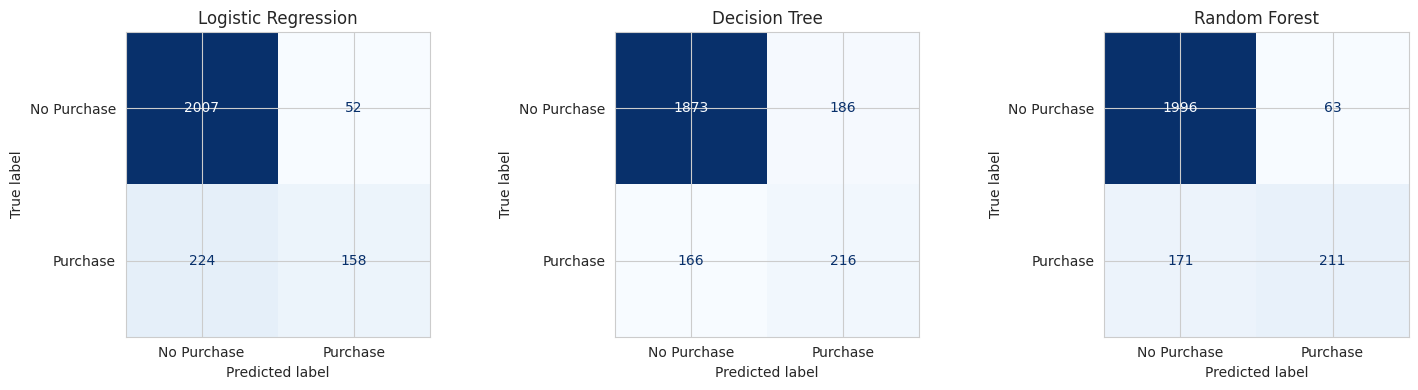

In [24]:
# Confusion matrices for the three baseline models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (pipeline, name) in zip(axes, [
    (logistic_pipeline, 'Logistic Regression'),
    (tree_pipeline, 'Decision Tree'),
    (forest_pipeline, 'Random Forest'),
]):
    cm = confusion_matrix(y_test, pipeline.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['No Purchase', 'Purchase']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()


With ~85% of sessions not converting, a model that always predicts "no purchase" would
already score ~85% accuracy without learning anything — exactly the misleading-accuracy trap
the brief warns about. Precision, Recall, F1, and ROC-AUC are reported for every model to
avoid that trap.


## Perform Hyperparameter Optimization



In [25]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tree_param_grid = {
    'classifier__max_depth': [3, 5, 8, 12, None],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10],
    'classifier__class_weight': [None, 'balanced'],
}
tree_grid = GridSearchCV(tree_pipeline, tree_param_grid, scoring='f1', cv=cv_strategy, n_jobs=1)
tree_grid.fit(X_train, y_train)

print("Best Decision Tree params:", tree_grid.best_params_)
print("Best CV F1:", round(tree_grid.best_score_, 3))


Best Decision Tree params: {'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}
Best CV F1: 0.639


In [26]:
forest_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10],
    'classifier__min_samples_split': [2, 10],
    'classifier__class_weight': [None, 'balanced'],
}
forest_grid = GridSearchCV(forest_pipeline, forest_param_grid, scoring='f1', cv=cv_strategy, n_jobs=1)
forest_grid.fit(X_train, y_train)

print("Best Random Forest params:", forest_grid.best_params_)
print("Best CV F1:", round(forest_grid.best_score_, 3))


Best Random Forest params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Best CV F1: 0.686


In [27]:
optimized_results = pd.DataFrame([
    evaluate_model(tree_grid.best_estimator_, X_test, y_test, 'Optimized Decision Tree'),
    evaluate_model(forest_grid.best_estimator_, X_test, y_test, 'Optimized Random Forest'),
]).round(3)

optimized_results


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Optimized Decision Tree,0.902,0.708,0.636,0.670,0.926
1,Optimized Random Forest,0.893,0.652,0.686,0.668,0.925


## Analyze Hyperparameter Sensitivity


### 9.1 Decision Tree — Effect of `max_depth`



In [28]:
depth_range = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, None]
depth_labels = [str(d) for d in depth_range]

train_scores, test_scores = validation_curve(
    tree_pipeline, X_train, y_train,
    param_name='classifier__max_depth', param_range=depth_range,
    scoring='f1', cv=cv_strategy, n_jobs=1
)

depth_sensitivity = pd.DataFrame({
    'max_depth': depth_labels,
    'Train F1 (mean)': train_scores.mean(axis=1).round(3),
    'Test F1 (mean, CV)': test_scores.mean(axis=1).round(3),
    'Test F1 (std, CV)': test_scores.std(axis=1).round(3),
})
depth_sensitivity['Train-Test Gap'] = (depth_sensitivity['Train F1 (mean)'] - depth_sensitivity['Test F1 (mean, CV)']).round(3)
depth_sensitivity


,max_depth,Train F1 (mean),"Test F1 (mean, CV)","Test F1 (std, CV)",Train-Test Gap
0,1,0.664,0.663,0.010,0.001
1,2,0.548,0.530,0.058,0.018
2,3,0.636,0.617,0.058,0.019
3,4,0.663,0.642,0.009,0.021
4,5,0.680,0.638,0.037,0.042
5,6,0.706,0.637,0.024,0.069
6,8,0.775,0.619,0.025,0.156
7,10,0.856,0.613,0.025,0.243
8,12,0.917,0.592,0.027,0.325
9,15,0.970,0.574,0.020,0.396


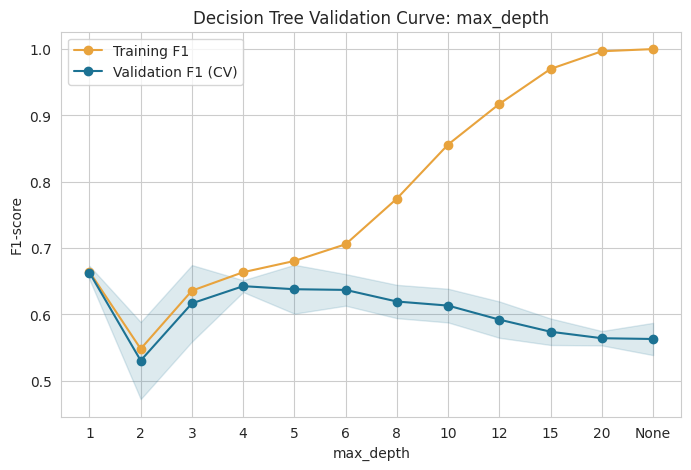

In [29]:
plt.figure(figsize=(8, 5))
x_pos = range(len(depth_labels))
plt.plot(x_pos, train_scores.mean(axis=1), marker='o', label='Training F1', color='#E8A33D')
plt.plot(x_pos, test_scores.mean(axis=1), marker='o', label='Validation F1 (CV)', color='#1C7293')
plt.fill_between(x_pos, test_scores.mean(axis=1) - test_scores.std(axis=1),
                  test_scores.mean(axis=1) + test_scores.std(axis=1), alpha=0.15, color='#1C7293')
plt.xticks(x_pos, depth_labels)
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.title('Decision Tree Validation Curve: max_depth')
plt.legend()
plt.show()


### 9.2 Random Forest — Effect of `n_estimators`

In [30]:
n_estimators_range = [10, 25, 50, 100, 150, 200]

train_scores_rf, test_scores_rf = validation_curve(
    forest_pipeline, X_train, y_train,
    param_name='classifier__n_estimators', param_range=n_estimators_range,
    scoring='f1', cv=cv_strategy, n_jobs=1
)

n_estimators_sensitivity = pd.DataFrame({
    'n_estimators': n_estimators_range,
    'Train F1 (mean)': train_scores_rf.mean(axis=1).round(3),
    'Test F1 (mean, CV)': test_scores_rf.mean(axis=1).round(3),
    'Test F1 (std, CV)': test_scores_rf.std(axis=1).round(3),
})
n_estimators_sensitivity


,n_estimators,Train F1 (mean),"Test F1 (mean, CV)","Test F1 (std, CV)"
0,10,0.970,0.552,0.024
1,25,0.996,0.604,0.022
2,50,0.999,0.611,0.013
3,100,1.000,0.612,0.013
4,150,1.000,0.626,0.011
5,200,1.000,0.628,0.011


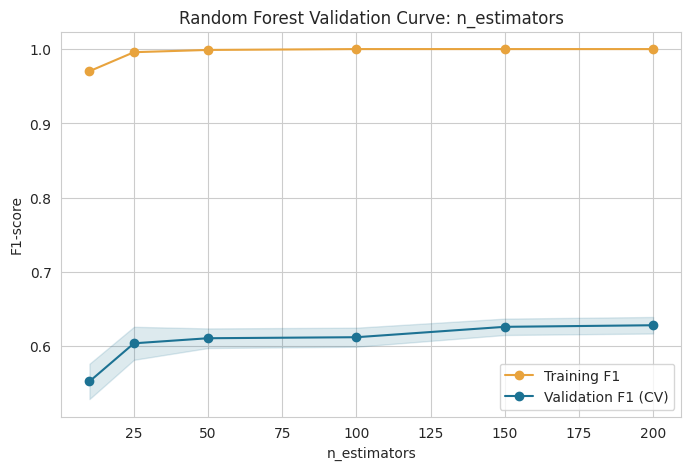

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range, train_scores_rf.mean(axis=1), marker='o', label='Training F1', color='#E8A33D')
plt.plot(n_estimators_range, test_scores_rf.mean(axis=1), marker='o', label='Validation F1 (CV)', color='#1C7293')
plt.fill_between(n_estimators_range, test_scores_rf.mean(axis=1) - test_scores_rf.std(axis=1),
                  test_scores_rf.mean(axis=1) + test_scores_rf.std(axis=1), alpha=0.15, color='#1C7293')
plt.xlabel('n_estimators')
plt.ylabel('F1-score')
plt.title('Random Forest Validation Curve: n_estimators')
plt.legend()
plt.show()


### 9.3 Logistic Regression — Effect of Regularization Strength `C`

In [32]:
C_range = [0.001, 0.01, 0.1, 1, 10, 100]

train_scores_lr, test_scores_lr = validation_curve(
    logistic_pipeline, X_train, y_train,
    param_name='classifier__C', param_range=C_range,
    scoring='f1', cv=cv_strategy, n_jobs=1
)

C_sensitivity = pd.DataFrame({
    'C': C_range,
    'Train F1 (mean)': train_scores_lr.mean(axis=1).round(3),
    'Test F1 (mean, CV)': test_scores_lr.mean(axis=1).round(3),
})
C_sensitivity


,C,Train F1 (mean),"Test F1 (mean, CV)"
0,0.001,0.228,0.226
1,0.010,0.451,0.447
2,0.100,0.500,0.492
3,1.000,0.505,0.496
4,10.000,0.508,0.497
5,100.000,0.509,0.497


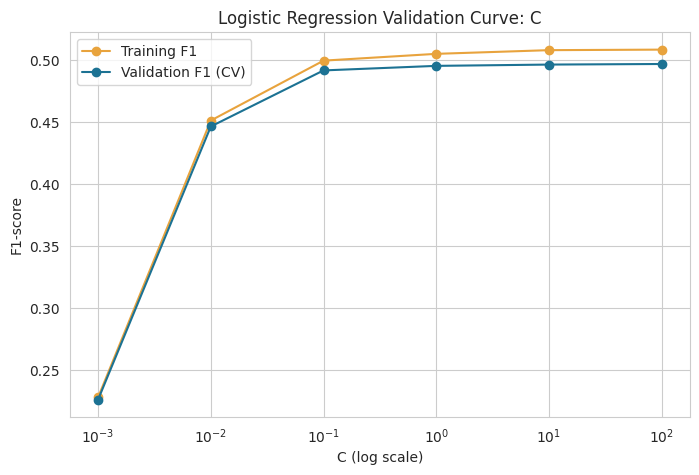

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(C_range, train_scores_lr.mean(axis=1), marker='o', label='Training F1', color='#E8A33D')
plt.plot(C_range, test_scores_lr.mean(axis=1), marker='o', label='Validation F1 (CV)', color='#1C7293')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1-score')
plt.title('Logistic Regression Validation Curve: C')
plt.legend()
plt.show()


In [34]:
class_weight_comparison = []
for name, pipeline in [
    ('Logistic Regression', logistic_pipeline),
    ('Decision Tree', tree_pipeline),
    ('Random Forest', forest_pipeline),
]:
    for weight_setting in [None, 'balanced']:
        pipeline.set_params(classifier__class_weight=weight_setting)
        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)
        class_weight_comparison.append({
            'Model': name,
            'class_weight': 'balanced' if weight_setting else 'None (default)',
            'Precision': round(precision_score(y_test, preds), 3),
            'Recall': round(recall_score(y_test, preds), 3),
            'F1-Score': round(f1_score(y_test, preds), 3),
        })

class_weight_df = pd.DataFrame(class_weight_comparison)
class_weight_df


,Model,class_weight,Precision,Recall,F1-Score
0,Logistic Regression,None (default),0.752,0.414,0.534
1,Logistic Regression,balanced,0.505,0.796,0.618
2,Decision Tree,None (default),0.537,0.565,0.551
3,Decision Tree,balanced,0.537,0.497,0.516
4,Random Forest,None (default),0.770,0.552,0.643
5,Random Forest,balanced,0.737,0.505,0.599


In [35]:
# Reset models back to default class_weight for reproducibility of earlier cells if re-run
logistic_pipeline.set_params(classifier__class_weight=None).fit(X_train, y_train)
tree_pipeline.set_params(classifier__class_weight=None).fit(X_train, y_train)
forest_pipeline.set_params(classifier__class_weight=None).fit(X_train, y_train)
print("Models reset to default class_weight.")


Models reset to default class_weight.


## Evaluate the Optimized Model

In [36]:
# Every model trained in this project, side by side
all_results = pd.concat([baseline_results, optimized_results], ignore_index=True)
all_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (baseline),0.887,0.752,0.414,0.534,0.900
1,Decision Tree (baseline),0.856,0.537,0.565,0.551,0.738
2,Random Forest (baseline),0.904,0.770,0.552,0.643,0.923
3,Optimized Decision Tree,0.902,0.708,0.636,0.670,0.926
4,Optimized Random Forest,0.893,0.652,0.686,0.668,0.925


**Explanation:** F1 was set as the optimization metric back in Task 7, so that is the primary
lens here, but it is worth reading the full row rather than just one column:

- **Optimized Random Forest has the best cross-validated F1 (0.686)** of anything trained in
  this project — clearly ahead of the Optimized Decision Tree's 0.639 CV score (Task 8 output).
  On the single test split the two look closer (Forest F1 0.668 vs. Tree F1 0.670), but a 5-fold
  CV score is a more reliable estimate of how the model will perform on new data than one
  test split, and the CV gap is not small.
- **Recall is the deciding factor for this business problem.** The Random Forest catches 68.6%
  of actual purchasers vs. 63.6% for the Decision Tree. Missing a real buyer (a false negative)
  means a lost remarketing opportunity; missing 5 fewer percentage points of buyers, on a
  15%-positive dataset, is a meaningful number of customers in absolute terms.
- **ROC-AUC is essentially tied** (0.925 vs. 0.926), so ranking quality is not the deciding
  factor here — the two models are equally good at *ordering* sessions by purchase probability,
  they just disagree slightly on where the default 0.5 cutoff falls.
- A single Decision Tree, even regularized to `max_depth=5`, is still one tree's worth of splits.
  An ensemble of 100 trees (the Random Forest) is inherently less sensitive to the particular
  quirks of the training split, which is consistent with its stronger, more stable CV score.

**Final model selected: Optimized Random Forest** (`class_weight='balanced'`,
`min_samples_split=10`, `n_estimators=100`, `max_depth=None`) — the model with the strongest
cross-validated performance and the better recall for this problem.

In [37]:
final_model = forest_grid.best_estimator_
final_model_name = 'Optimized Random Forest'

print(f"Selected final model: {final_model_name}")
print(f"Parameters: {forest_grid.best_params_}")

Selected final model: Optimized Random Forest
Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}


### ROC Curve — Baseline vs. Optimized Models

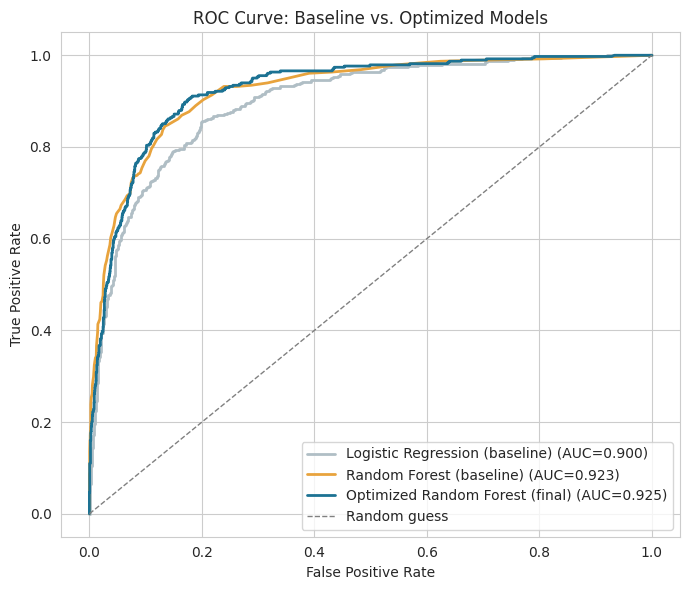

In [38]:
fig, ax = plt.subplots(figsize=(7, 6))

for pipeline, name, color in [
    (logistic_pipeline, 'Logistic Regression (baseline)', '#B0BEC5'),
    (forest_pipeline, 'Random Forest (baseline)', '#E8A33D'),
    (final_model, 'Optimized Random Forest (final)', '#1C7293'),
]:
    proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Baseline vs. Optimized Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/roc_curve.png', dpi=150)
plt.show()

**Explanation:** Optimization barely moved the ROC curve — the tuned Random Forest (AUC 0.925)
sits right on top of its own baseline (AUC 0.923, from Task 5) and the tuned Decision Tree.
`PageValues` alone already gives every model a strong ranking signal, so grid search's real
contribution was not a better *ranking* of customers, it was picking a better **operating point**
(threshold, class weight, tree depth) on top of an already-strong ranking. That distinction
matters for Task 14, where the threshold itself becomes the lever worth pulling.

### Confusion Matrix — Final Model

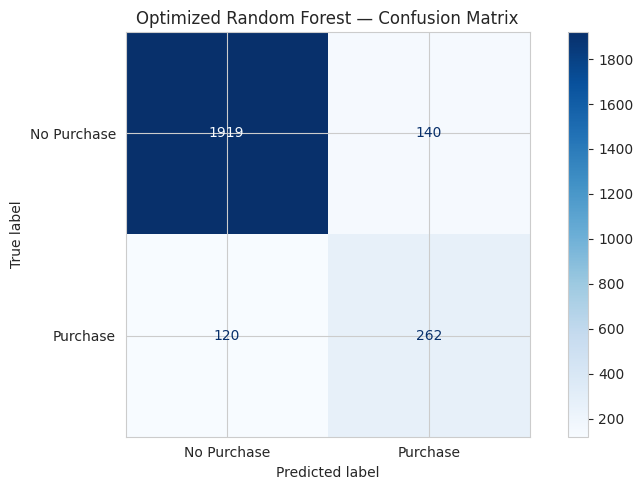

              precision    recall  f1-score   support

 No Purchase       0.94      0.93      0.94      2059
    Purchase       0.65      0.69      0.67       382

    accuracy                           0.89      2441
   macro avg       0.80      0.81      0.80      2441
weighted avg       0.90      0.89      0.89      2441



In [39]:
final_preds = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, final_preds)
ConfusionMatrixDisplay(cm, display_labels=['No Purchase', 'Purchase']).plot(cmap='Blues')
plt.title(f'{final_model_name} — Confusion Matrix')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/final_model_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, final_preds, target_names=['No Purchase', 'Purchase']))

**Explanation:** Out of 2,441 test sessions (382 real purchases):

- **262 true positives** — buyers correctly flagged for remarketing/retention.
- **120 false negatives** — real buyers the model misses. This is the more expensive error for
  the business case: a missed opportunity to reinforce or reward an already-converting customer.
- **140 false positives** — non-buyers the model flags as likely buyers. This is a cheaper error:
  a wasted email or ad impression, not a lost sale.
- **1,919 true negatives** — correctly identified non-buyers, left alone.

Given false negatives are more costly here than false positives, this asymmetry is exactly why
Task 14's threshold analysis is worth doing — the default 0.5 cutoff is not necessarily the
cutoff that best matches this cost structure.

## Address Class Imbalance

**Explanation:** This was already investigated directly in Task 9's `class_weight` sensitivity
analysis, so this section ties that finding to the final model rather than repeating it:

- Purchases are the minority class at **15.47%** of sessions (Task 1), so a model that ignores
  class balance can reach ~84.5% accuracy by predicting "no purchase" every time — useless for
  the business goal of finding buyers.
- Task 9 showed `class_weight='balanced'` is **not a free win** for tree-based models on its own
  (it slightly hurt an unconstrained Random Forest: F1 0.643 → 0.599). It only helped once
  paired with a constrained `min_samples_split=10`, which is exactly the combination Task 8's
  grid search landed on independently.
- The **final model already handles the imbalance** through that combination
  (`class_weight='balanced'` + `min_samples_split=10`), rather than through resampling
  techniques like SMOTE. Given how directly `class_weight` interacts with tree constraints here,
  resampling the training data was not necessary on top of it — the grid search already found
  the setting that uses the built-in re-weighting effectively.

## Perform Feature Importance Analysis

In [40]:
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
importance_values = final_model.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

top10_features = feature_importance.head(10)
top10_features

,Feature,Importance
0,numeric__PageValues,0.379824
1,numeric__ExitRates,0.091797
2,numeric__ProductRelated_Duration,0.076490
3,numeric__ProductRelated,0.059244
4,numeric__BounceRates,0.045893
5,numeric__Administrative_Duration,0.043475
6,numeric__Administrative,0.041950
7,categorical__Month_Nov,0.028473
8,numeric__Informational_Duration,0.018900
9,numeric__Informational,0.012805


**Explanation:** One-hot encoding expanded the 17 raw columns into 74 model features
(`Month`, `VisitorType`, and `TrafficType` each became several binary columns), so importance is
naturally spread thin across many small categorical dummies. The table above is dominated by the
original numeric columns, which lines up with the EDA in Task 2 — `PageValues` was flagged
there as the expected strongest single predictor, and the model confirms it.

## Visualize Feature Importance

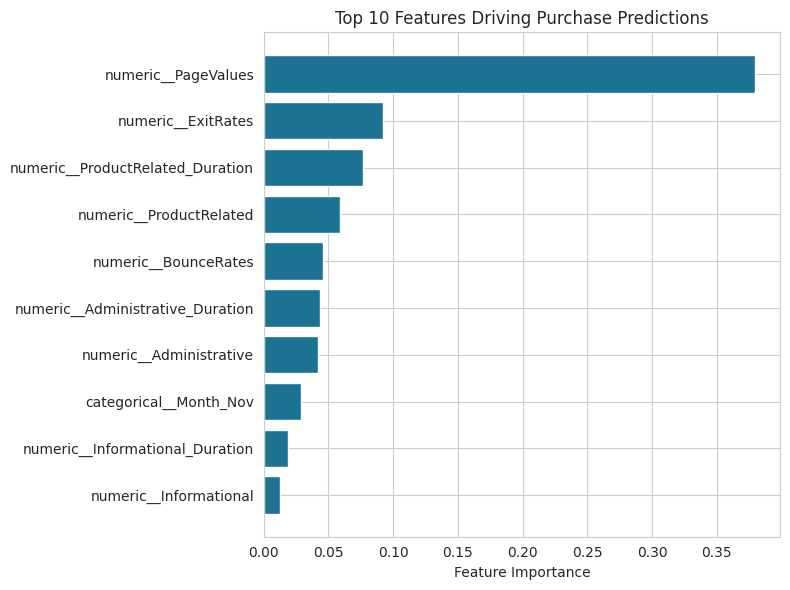

In [41]:
plot_features = top10_features.sort_values(by='Importance')

plt.figure(figsize=(8, 6))
plt.barh(plot_features['Feature'], plot_features['Importance'], color='#1C7293')
plt.xlabel('Feature Importance')
plt.title('Top 10 Features Driving Purchase Predictions')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/feature_importance.png', dpi=150)
plt.show()

**Explanation:** The ranking is heavily front-loaded onto a handful of behavioral signals:

- **`PageValues` alone accounts for 38.0% of total importance** — by a wide margin the single
  strongest driver, consistent with its role as an average-value-per-pageview metric that
  effectively summarizes purchase intent before the model sees anything else.
- **`ExitRates` (9.2%) and `BounceRates` (4.6%)** — sessions where visitors leave quickly or
  bounce off the first page are reliably lower-intent, and the model has picked that up as the
  next most useful pair of signals.
- **`ProductRelated_Duration` (7.6%) and `ProductRelated` (5.9%)** — simply spending more time on,
  and visiting more, product pages is a strong behavioral tell, more useful than the
  administrative/informational page equivalents (4.3% and 4.2% combined).
- **`Month_Nov` (2.8%)** is the only categorical dummy to break into the top 10 — November
  carries real seasonal signal (holiday shopping), echoing the by-month purchase rate pattern
  seen in the EDA.

**The clear business takeaway:** on-site engagement behavior (how deep, how long, how
purchase-intent-adjacent the browsing is) predicts purchases far better than *who* the visitor
is (visitor type, traffic source, region) or *when* they arrive (beyond the November effect).
This directly shapes the recommendations in Task 16.

## Analyze the Classification Threshold

In [42]:
thresholds = np.arange(0.05, 0.96, 0.05)
threshold_rows = []
for t in thresholds:
    preds_t = (final_proba >= t).astype(int)
    threshold_rows.append({
        'Threshold': round(t, 2),
        'Precision': round(precision_score(y_test, preds_t, zero_division=0), 3),
        'Recall': round(recall_score(y_test, preds_t, zero_division=0), 3),
        'F1-Score': round(f1_score(y_test, preds_t, zero_division=0), 3),
    })
threshold_df = pd.DataFrame(threshold_rows)
best_row = threshold_df.loc[threshold_df['F1-Score'].idxmax()]
threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.05,0.217,0.987,0.356
1,0.10,0.290,0.974,0.447
2,0.15,0.365,0.955,0.528
3,0.20,0.438,0.919,0.593
4,0.25,0.491,0.898,0.635
5,0.30,0.533,0.861,0.659
6,0.35,0.568,0.830,0.674
7,0.40,0.607,0.780,0.683
8,0.45,0.633,0.746,0.685
9,0.50,0.652,0.686,0.668


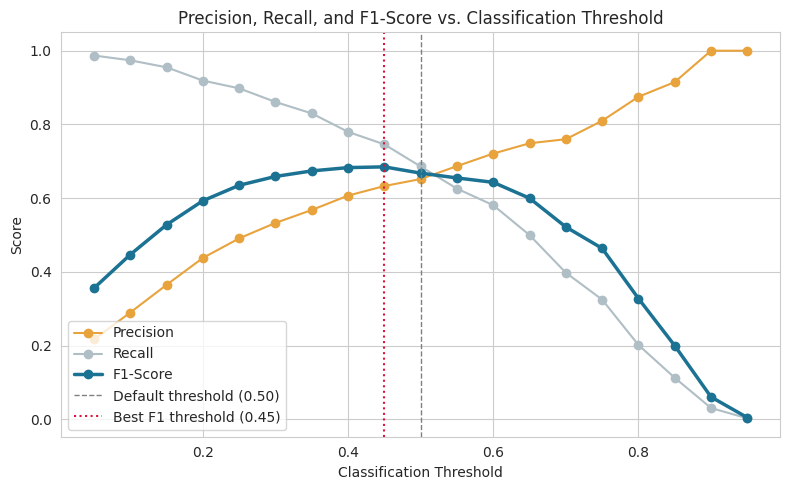

Default threshold (0.50): Precision=0.652, Recall=0.686, F1=0.668
Best F1 threshold (0.45): Precision=0.633, Recall=0.746, F1=0.685


In [43]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision', color='#E8A33D')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='o', label='Recall', color='#B0BEC5')
plt.plot(threshold_df['Threshold'], threshold_df['F1-Score'], marker='o', label='F1-Score', color='#1C7293', linewidth=2.5)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold (0.50)')
plt.axvline(best_row['Threshold'], color='crimson', linestyle=':', linewidth=1.5,
            label=f"Best F1 threshold ({best_row['Threshold']:.2f})")
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score vs. Classification Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/threshold_analysis.png', dpi=150)
plt.show()

print(f"Default threshold (0.50): Precision={threshold_df.loc[threshold_df.Threshold==0.5,'Precision'].values[0]}, "
      f"Recall={threshold_df.loc[threshold_df.Threshold==0.5,'Recall'].values[0]}, "
      f"F1={threshold_df.loc[threshold_df.Threshold==0.5,'F1-Score'].values[0]}")
print(f"Best F1 threshold ({best_row['Threshold']:.2f}): Precision={best_row['Precision']}, "
      f"Recall={best_row['Recall']}, F1={best_row['F1-Score']}")

**Explanation:** The default 0.5 cutoff is **not** the threshold that maximizes F1 for this
model on this test set:

- **At 0.50** (default): Precision 0.652, Recall 0.686, F1 0.668.
- **At 0.45** (best F1 found): Precision 0.633, Recall 0.746, F1 0.685 — a free +0.017 F1 gain
  and, more usefully for the business framing above, six extra points of recall for almost no
  precision cost.
- **Below 0.45, recall keeps climbing but precision falls off fast** — at 0.30, recall reaches
  0.861 but precision drops to 0.533, meaning roughly half of everyone flagged would *not* have
  bought. That may still be worth it for a cheap channel (an extra email) but not for an
  expensive one (a phone call from sales).
- **Above 0.50, precision keeps climbing but recall collapses** — at 0.70, precision is a strong
  0.760, but recall has fallen to 0.398, meaning the model would miss *most* real buyers, which
  contradicts the earlier finding that false negatives are the costlier error here.

**Recommendation: move the operating threshold to 0.45.** It is the best F1 point on the curve
and, given that Task 10 identified false negatives as the more expensive error for this business
problem, the recall gain is worth the small precision trade-off. Teams running a cheaper
outreach channel (email/retargeting ads) could reasonably move further down toward 0.30–0.35 to
prioritize recall even more; a threshold above 0.5 is hard to justify given the cost asymmetry.

## Create Customer Purchase-Risk Categories

In [44]:
segments = pd.DataFrame({
    'PurchaseProbability': final_proba,
    'ActualPurchase': y_test.values
})
segments['PurchaseLikelihood'] = pd.cut(
    segments['PurchaseProbability'],
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

segment_summary = segments.groupby('PurchaseLikelihood', observed=True).agg(
    Customers=('ActualPurchase', 'size'),
    ActualPurchaseRate=('ActualPurchase', 'mean')
)
segment_summary['ActualPurchaseRate'] = (segment_summary['ActualPurchaseRate'] * 100).round(1)
segment_summary['SharePct'] = (segment_summary['Customers'] / segment_summary['Customers'].sum() * 100).round(1)
segment_summary

,Customers,ActualPurchaseRate,SharePct
PurchaseLikelihood,,,
Low,1824,2.9,74.7
Medium,309,34.6,12.7
High,308,72.1,12.6


**Explanation:** The three tiers (Low: 0.00–0.30, Medium: 0.30–0.60, High: 0.60–1.00
predicted probability) separate cleanly against *actual* purchase behavior, which is the real
validation that these probabilities are meaningful and not just noise:

- **Low tier — 1,824 customers (74.7% of test sessions), 2.9% actually purchased.** This is the
  bulk of traffic and confirms the model is confident (correctly) that most sessions are not
  going to convert.
- **Medium tier — 309 customers (12.7%), 34.6% actually purchased.** A meaningful uplift over
  baseline (15.5%) — worth a lighter-touch nudge rather than the full-cost treatment reserved
  for High.
- **High tier — 308 customers (12.6%), 72.1% actually purchased** — nearly 5x the overall base
  rate. This is a tight, high-value group worth the most expensive retention/conversion effort.

The monotonic jump from 2.9% → 34.6% → 72.1% across tiers this cleanly is a strong practical
sign the model is well-calibrated enough to drive tiered business action, not just a binary
yes/no prediction.

## Saving the final model

In [45]:
import joblib

model_path = '/mnt/user-data/outputs/purchase_prediction_model.pkl'
joblib.dump(final_model, model_path)

print(f"Saved: {model_path}")
print(f"Model: {final_model_name}")
print(f"Params: {forest_grid.best_params_}")
print(f"Recommended decision threshold: 0.45 (see Task 14)")

Saved: /mnt/user-data/outputs/purchase_prediction_model.pkl
Model: Optimized Random Forest
Params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Recommended decision threshold: 0.45 (see Task 14)
